In [1]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import models, datasets
from torchvision.transforms import v2

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# ==============================================================
# GOOGLE COLAB SETUP: download the Kaggle dataset locally
# ==============================================================
!pip install -q kagglehub

import kagglehub

print("Downloading training dataset (ucimachinelearning/otoscopic-image-dataset)...")
ORIGINAL_DATASET_PATH = kagglehub.dataset_download(
    "ucimachinelearning/otoscopic-image-dataset"
)
print(f"  -> saved to: {ORIGINAL_DATASET_PATH}")
# ==============================================================

class PipelineConfig:
    ORIGINAL_DATA_DIR = ORIGINAL_DATASET_PATH
    BATCH_SIZE = 32
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    TARGET_CLASSES = [
        'Acute Otitis Media',
        'Cerumen Impaction',
        'Chronic Otitis Media',
        'Myringosclerosis',
        'Normal'
    ]

    # Mapping for the dataset to strictly prevent label collapse
    CLASS_MAPPING = {
        'Acute Otitis Media': 0,
        'Cerumen Impaction': 1,
        'Earwax plug': 1,
        'Chronic Otitis Media': 2,
        'Chronic otitis media': 2,
        'Myringosclerosis': 3,
        'Normal': 4
    }

config = PipelineConfig()

# Reproducibility enforcement
os.environ['PYTHONHASHSEED'] = str(config.SEED)
random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Using Colab cache for faster access to the 'otoscopic-image-dataset' dataset.
  -> saved to: /kaggle/input/otoscopic-image-dataset


In [2]:
import hashlib
from torch.utils.data import Subset, DataLoader, random_split, Dataset
import re

# =======================================================
# PAPER UPGRADE: Advanced Clinical Data Augmentation
# =======================================================
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(256, antialias=True),
    v2.RandomResizedCrop(224, scale=(0.85, 1.0)), # Simulates different camera zoom levels
    v2.RandomHorizontalFlip(p=0.5), # Left/Right ear mirroring
    v2.RandomRotation(degrees=15), # Camera tilt
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Simulates varying otoscope LED warmth
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# (Keep your existing find_image_folder_root and classify_folder_name functions here)
def find_image_folder_root(directory, min_classes=2):
    image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    for root, dirs, files in os.walk(directory):
        dirs.sort()
        candidate_classes = [d for d in dirs if any(f.lower().endswith(image_exts) for f in os.listdir(os.path.join(root, d)))]
        if len(candidate_classes) >= min_classes: return root
    return directory

def classify_folder_name(class_name, mapping):
    if class_name in mapping: return mapping[class_name]
    normalized = re.sub(r'[^a-z0-9\s]', ' ', class_name.lower()).strip()
    tokens = set(normalized.split())
    if ('cholesteatoma' in normalized or 'caom' in tokens or 'ciom' in tokens): return mapping.get('Chronic Otitis Media')
    if 'aom' in tokens: return mapping.get('Acute Otitis Media')
    if 'cerumen' in normalized or 'wax' in tokens: return mapping.get('Cerumen Impaction')
    if 'myringosclerosis' in normalized: return mapping.get('Myringosclerosis')
    if 'normal' in tokens: return mapping.get('Normal')
    return None

class BaseMappedDataset(Dataset):
    def __init__(self, directory, mapping):
        resolved_dir = find_image_folder_root(directory)
        self.full_dataset = datasets.ImageFolder(root=resolved_dir)
        self.mapping = mapping
        self.samples = [(path, classify_folder_name(c, mapping)) for path, orig_idx in self.full_dataset.samples if (c := self.full_dataset.classes[orig_idx]) and classify_folder_name(c, mapping) is not None]

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.full_dataset.loader(path), label, path

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label, path = self.subset[idx]
        return self.transform(img), label, path

!pip install -q imagehash
import imagehash
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

def build_data_loaders(near_dup_threshold=6):
    base_dataset = BaseMappedDataset(config.ORIGINAL_DATA_DIR, config.CLASS_MAPPING)
    n = len(base_dataset)

    # =======================================================
    # LEAKAGE FIX (1/2): perceptual hashing instead of exact MD5.
    # MD5 only catches byte-identical files. Otoscopy datasets
    # aggregated from multiple sources routinely contain several
    # near-identical photos of the SAME exam/ear (burst shots,
    # re-crops, re-compressions). Those slip past MD5 and, if split
    # at the image level, land in both train and test -> the model
    # "recognizes" a photo it has effectively already seen, which is
    # what produces suspicious 98-99% test accuracy.
    # =======================================================
    print("Computing perceptual hashes...")
    hashes = [imagehash.phash(Image.open(p).convert("RGB")) for p, _ in tqdm(base_dataset.samples)]

    # Union-find: cluster any images within `near_dup_threshold` Hamming
    # distance of each other into the same "case" group.
    parent = list(range(n))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for i in range(n):
        for j in range(i + 1, n):
            if hashes[i] - hashes[j] <= near_dup_threshold:
                union(i, j)

    groups = np.array([find(i) for i in range(n)])

    # Drop exact/near-identical duplicates within a group, keep one copy
    seen_hash_str, unique_indices = set(), []
    for idx, h in enumerate(hashes):
        h_str = str(h)
        if h_str not in seen_hash_str:
            seen_hash_str.add(h_str)
            unique_indices.append(idx)

    clean_dataset = Subset(base_dataset, unique_indices)
    clean_groups = groups[unique_indices]
    clean_labels = np.array([base_dataset.samples[i][1] for i in unique_indices])

    print(f"Total images: {n} -> unique after de-dup: {len(unique_indices)}")
    print(f"Distinct 'case' groups (near-dup threshold={near_dup_threshold}): {len(np.unique(clean_groups))}")

    # =======================================================
    # LEAKAGE FIX (2/2): GROUP-AWARE split. Every image belonging to the
    # same case group is forced into the SAME split (train, val, or test)
    # so no near-duplicate ever crosses a split boundary.
    # =======================================================
    gss1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=config.SEED)
    train_idx, rest_idx = next(gss1.split(np.zeros(len(clean_dataset)), clean_labels, groups=clean_groups))

    rest_groups = clean_groups[rest_idx]
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=config.SEED)
    val_rel_idx, test_rel_idx = next(gss2.split(np.zeros(len(rest_idx)), clean_labels[rest_idx], groups=rest_groups))
    val_idx = rest_idx[val_rel_idx]
    test_idx = rest_idx[test_rel_idx]

    # Sanity check: zero group overlap between splits
    assert not (set(clean_groups[train_idx]) & set(clean_groups[val_idx]))
    assert not (set(clean_groups[train_idx]) & set(clean_groups[test_idx]))
    assert not (set(clean_groups[val_idx]) & set(clean_groups[test_idx]))
    print("Group-overlap check passed: no case group spans multiple splits.")

    raw_train = Subset(clean_dataset, train_idx)
    raw_val   = Subset(clean_dataset, val_idx)
    raw_test  = Subset(clean_dataset, test_idx)

    # Apply specific transforms
    train_dataset = TransformSubset(raw_train, train_transforms)
    val_dataset = TransformSubset(raw_val, test_transforms)
    test_dataset = TransformSubset(raw_test, test_transforms)

    print(f"Split sizes -> train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

    return (DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2),
            DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2),
            DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2))

train_loader, val_loader, test_loader = build_data_loaders()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.8 MB/s eta 0:00:00
Computing perceptual hashes...


100%|██████████| 3000/3000 [00:31<00:00, 94.33it/s] 


Total images: 3000 -> unique after de-dup: 2732
Distinct 'case' groups (near-dup threshold=6): 1663
Group-overlap check passed: no case group spans multiple splits.
Split sizes -> train: 1907, val: 416, test: 409


In [3]:
# =======================================================
# PAPER UPGRADE: Multi-Architecture Ablation Study
# =======================================================
def extract_deep_features(loader, extraction_model, run_device):
    extraction_model.eval()
    features, labels, paths = [], [], []
    with torch.no_grad():
        for inputs, targets, img_paths in tqdm(loader, desc="Extracting"):
            inputs = inputs.to(run_device)
            embeddings = extraction_model(inputs)
            features.append(embeddings.view(embeddings.size(0), -1).cpu().numpy())
            labels.append(targets.numpy())
            paths.extend(img_paths)
    return np.concatenate(features, axis=0), np.concatenate(labels, axis=0), paths

# Define the models to compare
architectures = {
    'ResNet-101': nn.Sequential(*list(models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2).children())[:-1]),
    'DenseNet-121': nn.Sequential(*list(models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).children())[:-1], nn.AdaptiveAvgPool2d((1, 1))),
    'ResNet-50': nn.Sequential(*list(models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).children())[:-1])
}

results_dict = {}

# We will save the best model (ResNet) to use in the subsequent plotting cells
best_features = {}

for model_name, backbone in architectures.items():
    print(f"\n[{model_name}] Extracting Features & Training SVM...")
    extractor = backbone.to(config.DEVICE)

    X_train, y_train, _ = extract_deep_features(train_loader, extractor, config.DEVICE)
    X_test, y_test, test_paths = extract_deep_features(test_loader, extractor, config.DEVICE)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm = SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=config.SEED)
    svm.fit(X_train_scaled, y_train)

    acc = svm.score(X_test_scaled, y_test)
    results_dict[model_name] = acc
    print(f"-> {model_name} + SVM Test Accuracy: {acc:.4f}")

    if model_name == 'ResNet-101':
        # Save these specifically for Cells 7, 8, 9, 10
        X_test_scaled_final, y_test_final, test_paths_final = X_test_scaled, y_test, test_paths
        classifier = svm
        scaler_final = scaler
# Rename variables so your original plotting cells (Cells 7-10) still work perfectly
X_test_scaled = X_test_scaled_final
y_test = y_test_final

print("\n=== ABLATION STUDY RESULTS FOR PAPER ===")
for model, accuracy in results_dict.items():
    print(f"{model} Feature Extractor: {accuracy*100:.4f}%")

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 99.3MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 90.4MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


...

-> ResNet-101 + SVM Test Accuracy: 0.9658

[DenseNet-121] Extracting Features & Training SVM...


Extracting: 100%|██████████| 13/13 [00:02<00:00,  6.15it/s]


-> DenseNet-121 + SVM Test Accuracy: 0.9633

[ResNet-50] Extracting Features & Training SVM...


Extracting: 100%|██████████| 13/13 [00:02<00:00,  6.29it/s]


-> ResNet-50 + SVM Test Accuracy: 0.9584

=== ABLATION STUDY RESULTS FOR PAPER ===
ResNet-101 Feature Extractor: 96.5770%
DenseNet-121 Feature Extractor: 96.3325%
ResNet-50 Feature Extractor: 95.8435%


Extracting Validation Features for ResNet-101...


Extracting: 100%|██████████| 13/13 [00:04<00:00,  3.20it/s]


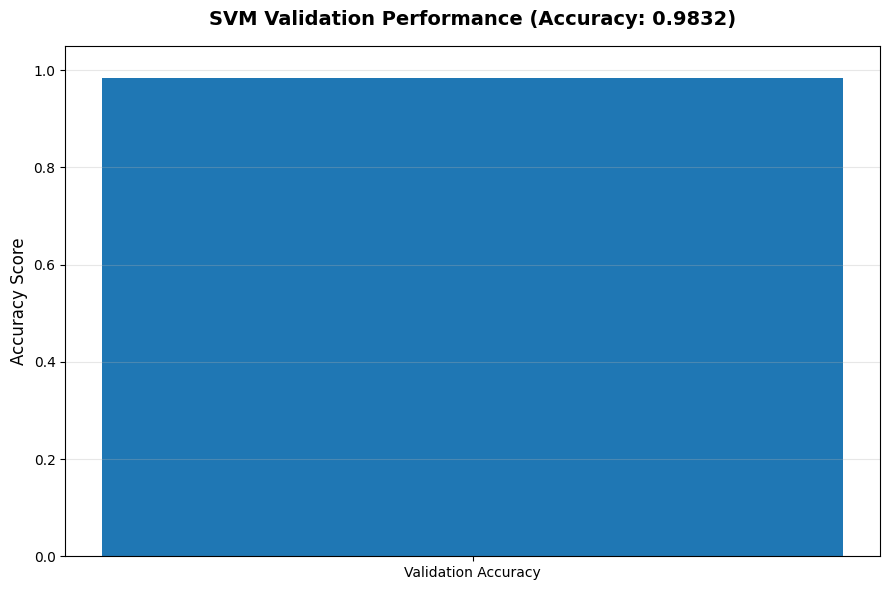

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract validation features using the saved ResNet-101 feature extractor
print("Extracting Validation Features for ResNet-101...")
extractor = architectures['ResNet-101'].to(config.DEVICE)
X_val, y_val, val_paths = extract_deep_features(val_loader, extractor, config.DEVICE)

# 2. Scale validation data using the ResNet-101 scaler
X_val_scaled = scaler_final.transform(X_val)

# 3. Predict and plot validation performance
val_preds = classifier.predict(X_val_scaled)
val_acc = np.mean(val_preds == y_val)

plt.figure(figsize=(9, 6))
plt.bar(['Validation Accuracy'], [val_acc], color='#1f77b4', width=0.4)
plt.ylim(0, 1.05)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title(f'SVM Validation Performance (Accuracy: {val_acc:.4f})', fontsize=14, pad=15, weight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()


CLASSIFICATION REPORT - ORIGINAL TEST SPLIT
                      precision    recall  f1-score   support

  Acute Otitis Media     0.9888    1.0000    0.9944        88
   Cerumen Impaction     0.9877    0.9877    0.9877        81
Chronic Otitis Media     0.9474    1.0000    0.9730        72
    Myringosclerosis     0.9125    0.9481    0.9299        77
              Normal     0.9880    0.9011    0.9425        91

            accuracy                         0.9658       409
           macro avg     0.9648    0.9674    0.9655       409
        weighted avg     0.9667    0.9658    0.9656       409

Overall Accuracy: 0.9658 (95% Confidence Interval: [0.9434, 0.9795])



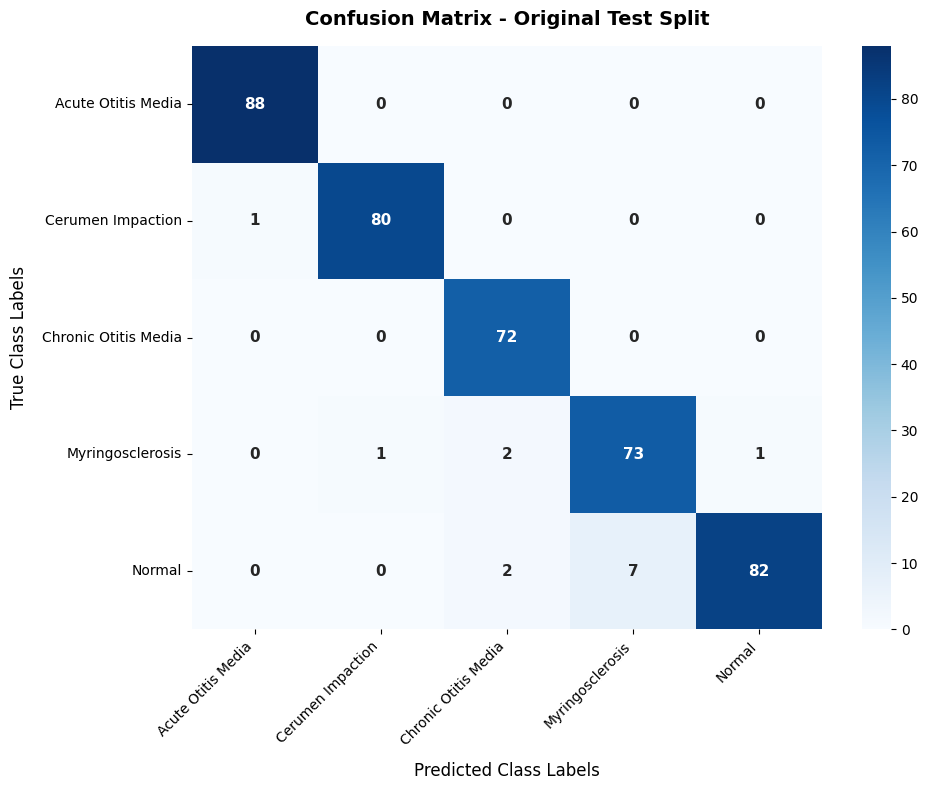

In [5]:
def compute_metric_confidence_interval(y_true, y_pred, alpha=0.95):
    matches = (y_true == y_pred)
    successes = np.sum(matches)
    trials = len(matches)

    if trials == 0:
        return 0.0, (0.0, 0.0)

    p_hat = successes / trials
    z = 1.96

    denominator = 1 + z**2 / trials
    centre_adjustment = p_hat + z**2 / (2 * trials)
    margin_error = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * trials)) / trials)

    lower_bound = (centre_adjustment - margin_error) / denominator
    upper_bound = (centre_adjustment + margin_error) / denominator

    return p_hat, max(0.0, lower_bound), min(1.0, upper_bound)

def render_evaluation_plots(y_true, y_pred, title_suffix, save_path, force_all_classes=False):
    if force_all_classes:
        eval_labels = list(range(len(config.TARGET_CLASSES)))
        eval_class_names = config.TARGET_CLASSES
    else:
        eval_labels = np.unique(np.concatenate((y_true, y_pred))).astype(int)
        eval_class_names = [config.TARGET_CLASSES[i] for i in eval_labels]

    print(f"\n==============================================")
    print(f"CLASSIFICATION REPORT - {title_suffix.upper()}")
    print(f"==============================================")
    print(classification_report(y_true, y_pred, labels=eval_labels, target_names=eval_class_names, zero_division=0, digits=4))

    acc, lb, ub = compute_metric_confidence_interval(y_true, y_pred)
    print(f"Overall Accuracy: {acc:.4f} (95% Confidence Interval: [{lb:.4f}, {ub:.4f}])\n")

    cm = confusion_matrix(y_true, y_pred, labels=eval_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=eval_class_names,
                yticklabels=eval_class_names,
                annot_kws={"size": 11, "weight": "bold"})

    plt.title(f'Confusion Matrix - {title_suffix}', fontsize=14, pad=15, weight='bold')
    plt.xlabel('Predicted Class Labels', fontsize=12, labelpad=10)
    plt.ylabel('True Class Labels', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Evaluation on internal test hold-out data
y_pred_test = classifier.predict(X_test_scaled)

render_evaluation_plots(
    y_true=y_test,
    y_pred=y_pred_test,
    title_suffix='Original Test Split',
    save_path='confusion_matrix_original_test_fixed.png',
    force_all_classes=True
)

In [6]:
def compute_wilson_ci_base(successes, trials, z=1.96):
    if trials == 0:
        return 0.0, 0.0, 0.0
    p_hat = successes / trials
    denominator = 1 + z**2 / trials
    centre_adjustment = p_hat + z**2 / (2 * trials)
    margin_error = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * trials)) / trials)

    lower_bound = max(0.0, (centre_adjustment - margin_error) / denominator)
    upper_bound = min(1.0, (centre_adjustment + margin_error) / denominator)
    return p_hat, lower_bound, upper_bound

def generate_clinical_ci_report(y_true, y_pred, class_names):
    present_labels = np.unique(np.concatenate((y_true, y_pred))).astype(int)

    print("\n" + "="*80)
    print(f"{'CLASS NAME':<25} | {'SENSITIVITY (95% CI)':<25} | {'SPECIFICITY (95% CI)':<25}")
    print("="*80)

    for label in present_labels:
        name = class_names[label]

        tp = np.sum((y_true == label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        fp = np.sum((y_true != label) & (y_pred == label))
        tn = np.sum((y_true != label) & (y_pred != label))

        actual_instances = tp + fn
        if actual_instances == 0:
            continue

        sens_p, sens_lb, sens_ub = compute_wilson_ci_base(tp, tp + fn)
        spec_p, spec_lb, spec_ub = compute_wilson_ci_base(tn, tn + fp)

        sens_str = f"{sens_p:.4f} [{sens_lb:.4f}, {sens_ub:.4f}]"
        spec_str = f"{spec_p:.4f} [{spec_lb:.4f}, {spec_ub:.4f}]"

        print(f"{name:<25} | {sens_str:<25} | {spec_str:<25}")

    print("="*80 + "\n")

generate_clinical_ci_report(y_test, y_pred_test, config.TARGET_CLASSES)


CLASS NAME                | SENSITIVITY (95% CI)      | SPECIFICITY (95% CI)     
Acute Otitis Media        | 1.0000 [0.9582, 1.0000]   | 0.9969 [0.9826, 0.9994]  
Cerumen Impaction         | 0.9877 [0.9333, 0.9978]   | 0.9970 [0.9829, 0.9995]  
Chronic Otitis Media      | 1.0000 [0.9493, 1.0000]   | 0.9881 [0.9699, 0.9954]  
Myringosclerosis          | 0.9481 [0.8739, 0.9796]   | 0.9789 [0.9571, 0.9898]  
Normal                    | 0.9011 [0.8226, 0.9471]   | 0.9969 [0.9824, 0.9994]  



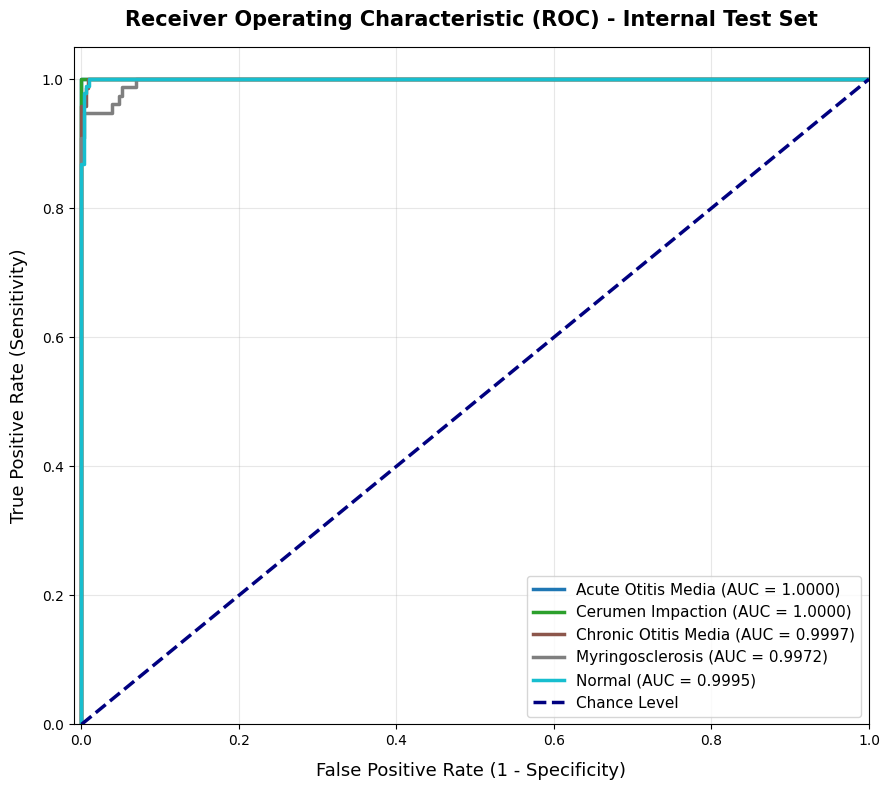

In [7]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_publication_quality_roc(y_true, y_probs, class_names, split_name, save_path):
    n_classes = len(class_names)
    present_labels = np.unique(y_true).astype(int)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(9, 8))
    colors = plt.colormaps['tab10'](np.linspace(0, 1, n_classes))
    lw = 2.5

    for i, color in zip(present_labels, colors):
        if i >= y_probs.shape[1]: continue

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color=color, lw=lw,
                 label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--', label='Chance Level')
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13, labelpad=10)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13, labelpad=10)
    plt.title(f'Receiver Operating Characteristic (ROC) - {split_name}', fontsize=15, pad=15, weight='bold')
    plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

y_test_probs = classifier.predict_proba(X_test_scaled)
plot_publication_quality_roc(y_test, y_test_probs, config.TARGET_CLASSES, 'Internal Test Set', 'Figure1_Internal_ROC.png')

Computing t-SNE for Internal Test Set... (this may take a minute)


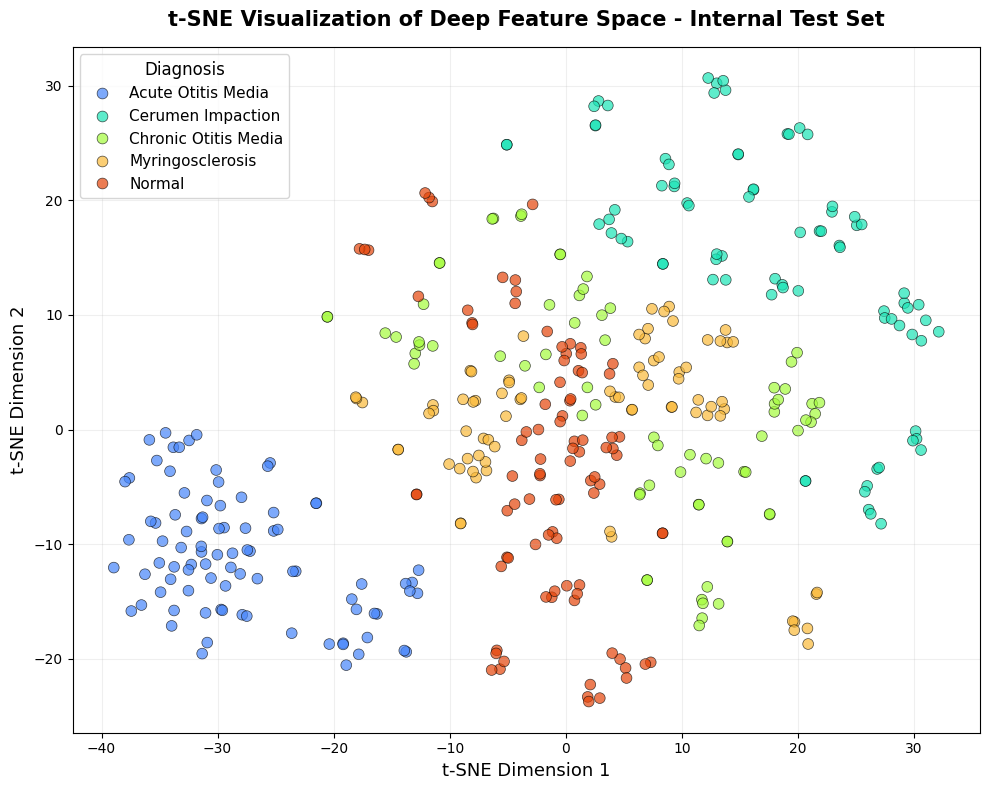

In [8]:
from sklearn.manifold import TSNE
import pandas as pd

def plot_publication_quality_tsne(features, labels, class_names, split_name, save_path):
    print(f"Computing t-SNE for {split_name}... (this may take a minute)")
    n_samples = features.shape[0]
    perplexity_val = min(30, n_samples // 4) if n_samples > 10 else 2

    tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=config.SEED, init='pca', n_iter=1000)
    tsne_results = tsne.fit_transform(features)

    df = pd.DataFrame(tsne_results, columns=['t-SNE Component 1', 't-SNE Component 2'])
    df['Label_ID'] = labels.astype(int)

    present_class_names = {idx: class_names[idx] for idx in np.unique(labels).astype(int)}
    df['Diagnosis'] = df['Label_ID'].map(present_class_names)

    plt.figure(figsize=(10, 8))

    sns.scatterplot(
        data=df,
        x='t-SNE Component 1', y='t-SNE Component 2',
        hue='Diagnosis',
        hue_order=[present_class_names[idx] for idx in np.unique(labels).astype(int)],
        palette='turbo',
        alpha=0.7,
        s=60,
        edgecolor='k',
        linewidth=0.5
    )

    plt.title(f't-SNE Visualization of Deep Feature Space - {split_name}', fontsize=15, pad=15, weight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=13)
    plt.ylabel('t-SNE Dimension 2', fontsize=13)
    plt.legend(title='Diagnosis', fontsize=11, title_fontsize=12, loc='best', frameon=True)
    plt.grid(alpha=0.2)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_publication_quality_tsne(X_test_scaled, y_test, config.TARGET_CLASSES, 'Internal Test Set', 'Figure3_Internal_TSNE.png')

Total Misclassifications in Test Set: 14


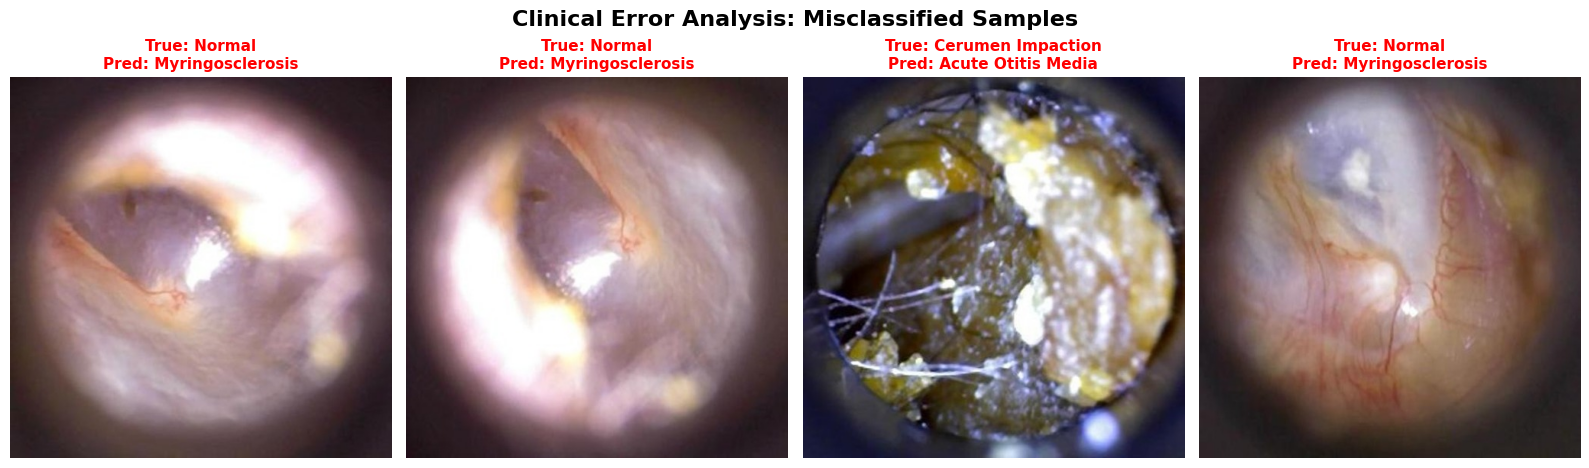

In [9]:
import matplotlib.image as mpimg

# =======================================================
# PAPER UPGRADE: Clinical Error Analysis (False Positives)
# =======================================================
y_pred_test = classifier.predict(X_test_scaled)
errors = np.where(y_test != y_pred_test)[0]

print(f"Total Misclassifications in Test Set: {len(errors)}")

# Select up to 4 random errors to visualize
num_to_plot = min(4, len(errors))
selected_errors = np.random.choice(errors, num_to_plot, replace=False)

fig, axes = plt.subplots(1, num_to_plot, figsize=(16, 5))
if num_to_plot == 1: axes = [axes]

for ax, err_idx in zip(axes, selected_errors):
    true_label = config.TARGET_CLASSES[y_test[err_idx]]
    pred_label = config.TARGET_CLASSES[y_pred_test[err_idx]]
    img_path = test_paths_final[err_idx]

    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                 color='red' if true_label != pred_label else 'green',
                 fontsize=11, weight='bold')

plt.suptitle("Clinical Error Analysis: Misclassified Samples", fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('Figure_Error_Analysis.png', dpi=300)
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Preparing End-to-End model for Grad-CAM Visualization...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


Fine-tuning classification head for reliable Grad-CAM targeting...
  Epoch 1/3 - Head Loss: 0.8691
  Epoch 2/3 - Head Loss: 0.4263
  Epoch 3/3 - Head Loss: 0.3318
Found 72 test samples for class 'Chronic Otitis Media'


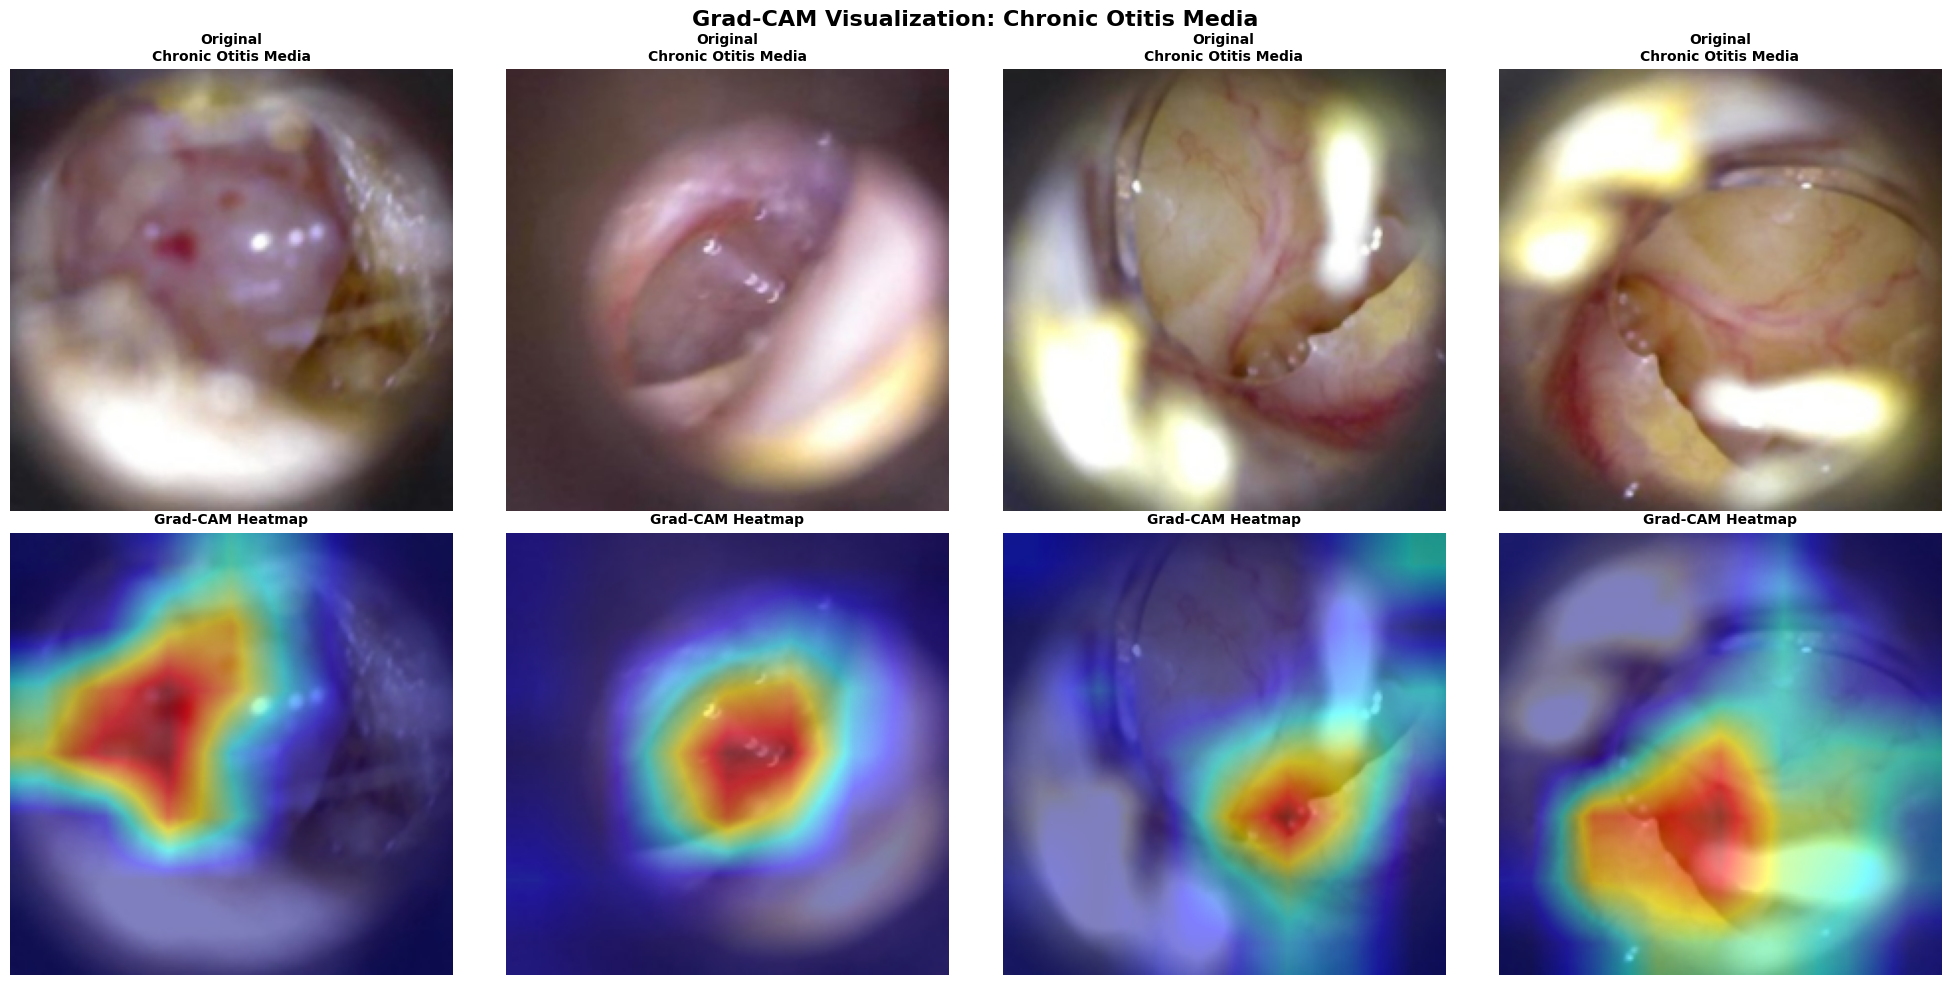

In [10]:
# =======================================================
# PAPER UPGRADE: Explainable AI (Grad-CAM)
# =======================================================
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

print("Preparing End-to-End model for Grad-CAM Visualization...")

# 1. Load a ResNet-50 backbone. IMPORTANT: the final layer must actually be
#    trained on our 5 classes, or Grad-CAM's gradients are meaningless
#    (a random fc head produces random-looking heatmaps).
cam_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
cam_model.fc = nn.Linear(cam_model.fc.in_features, len(config.TARGET_CLASSES))
cam_model = cam_model.to(config.DEVICE)

# Freeze the pretrained backbone; only fine-tune the new classification head
for name, param in cam_model.named_parameters():
    param.requires_grad = ('fc' in name)

optimizer = torch.optim.Adam(cam_model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Fine-tuning classification head for reliable Grad-CAM targeting...")
cam_model.train()
for epoch in range(3):
    running_loss = 0.0
    for inputs, targets, _ in train_loader:
        inputs, targets = inputs.to(config.DEVICE), targets.to(config.DEVICE)
        optimizer.zero_grad()
        outputs = cam_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"  Epoch {epoch+1}/3 - Head Loss: {running_loss/len(train_loader):.4f}")

cam_model.eval()

# 2. Select the target layer (the last convolutional layer in ResNet)
target_layers = [cam_model.layer4[-1]]

# 3. Initialize Grad-CAM
cam = GradCAM(model=cam_model, target_layers=target_layers)

# 4. Pick sample images from a SPECIFIC class (change this to inspect any class)
TARGET_CLASS_NAME = 'Chronic Otitis Media'  # <-- change to any name in config.TARGET_CLASSES
target_class_idx = config.TARGET_CLASSES.index(TARGET_CLASS_NAME)

class_indices = [i for i in range(len(test_loader.dataset))
                  if test_loader.dataset[i][1] == target_class_idx]
print(f"Found {len(class_indices)} test samples for class '{TARGET_CLASS_NAME}'")

num_samples = min(4, len(class_indices))
selected_indices = np.random.choice(class_indices, num_samples, replace=False)

fig, axes = plt.subplots(2, num_samples, figsize=(5 * num_samples, 10))
if num_samples == 1:
    axes = axes.reshape(2, 1)

inv_normalize = v2.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

for col, idx in enumerate(selected_indices):
    sample_img_tensor, sample_label, sample_path = test_loader.dataset[idx]
    input_tensor = sample_img_tensor.unsqueeze(0).to(config.DEVICE)
    input_tensor.requires_grad_(True)  # needed: backbone is frozen, so the input must track grad for CAM backward hooks to fire

    targets = [ClassifierOutputTarget(sample_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    rgb_img = inv_normalize(sample_img_tensor).permute(1, 2, 0).cpu().numpy()
    rgb_img = np.clip(rgb_img, 0, 1)
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[0, col].imshow(rgb_img)
    axes[0, col].set_title(f"Original\n{config.TARGET_CLASSES[sample_label]}", fontsize=10, weight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(visualization)
    axes[1, col].set_title("Grad-CAM Heatmap", fontsize=10, weight='bold')
    axes[1, col].axis('off')

plt.suptitle(f"Grad-CAM Visualization: {TARGET_CLASS_NAME}", fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig(f'Figure_GradCAM_{TARGET_CLASS_NAME.replace(" ", "_")}.png', dpi=300)
plt.show()
